In [25]:
import pandas as pd
import numpy as np

In [26]:
sm1 = pd.read_csv('./data/sample1.csv', index_col=0)
print(sm1.shape)
sm1.head(2)

(500000, 21)


,y,msg_length,max_discount,emoji_count,personalized,time_pressure,SRCH_EFRT,PRDV_CNT,CAT_CNT,SAMGE_PAGE_CNT,...,AVG_DEPTH,day_off,SEX_CD,AVG_SAL_AMT,AGE_30,AGE_50,AGE_60,AGE_1020,WEEKDAY,WEEKEND
0,0,30,32.0,0,0,0,6,2,0,2,...,24.285714,1,1,21490.0,0,0,0,0,4,0
1,0,41,0.0,0,0,0,15,4,0,4,...,16.666667,0,1,26085.0,0,1,0,0,6,1


In [27]:
sm2 = pd.read_csv('./data/sample2.csv', index_col=0)
print(sm2.shape)
sm2.head(2)

(548036, 21)


,y,msg_length,max_discount,emoji_count,personalized,time_pressure,SRCH_EFRT,PRDV_CNT,CAT_CNT,SAMGE_PAGE_CNT,...,AVG_DEPTH,day_off,SEX_CD,AVG_SAL_AMT,AGE_30,AGE_50,AGE_60,AGE_1020,WEEKDAY,WEEKEND
500000,0,43,0.0,0,0,0,4,1,0,2,...,41.111111,0,1,290.322812,0,1,0,0,4,0
500001,0,43,0.0,0,0,0,4,1,0,2,...,50.909091,0,1,290.322812,0,1,0,0,5,1


In [28]:
df = pd.concat([sm1, sm2])
print(df.shape)
df.head(2)

(1048036, 21)


,y,msg_length,max_discount,emoji_count,personalized,time_pressure,SRCH_EFRT,PRDV_CNT,CAT_CNT,SAMGE_PAGE_CNT,...,AVG_DEPTH,day_off,SEX_CD,AVG_SAL_AMT,AGE_30,AGE_50,AGE_60,AGE_1020,WEEKDAY,WEEKEND
0,0,30,32.0,0,0,0,6,2,0,2,...,24.285714,1,1,21490.0,0,0,0,0,4,0
1,0,41,0.0,0,0,0,15,4,0,4,...,16.666667,0,1,26085.0,0,1,0,0,6,1


In [29]:
def determine_age(row):
    if row['AGE_30'] == 1:
        return 30
    elif row['AGE_50'] == 1:
        return 50
    elif row['AGE_60'] == 1:
        return 60
    elif row['AGE_1020'] == 1:
        return 20
    else:
        return 40  # 모든 값이 0이면 40

df['AGE'] = df.apply(determine_age, axis=1)
df.head(2)

,y,msg_length,max_discount,emoji_count,personalized,time_pressure,SRCH_EFRT,PRDV_CNT,CAT_CNT,SAMGE_PAGE_CNT,...,day_off,SEX_CD,AVG_SAL_AMT,AGE_30,AGE_50,AGE_60,AGE_1020,WEEKDAY,WEEKEND,AGE
0,0,30,32.0,0,0,0,6,2,0,2,...,1,1,21490.0,0,0,0,0,4,0,40
1,0,41,0.0,0,0,0,15,4,0,4,...,0,1,26085.0,0,1,0,0,6,1,50


In [67]:
import pandas as pd

# cat_cnt가 0보다 큰 데이터만 남기기
df_filtered = df[df['CAT_CNT'] > 0]

# 기초 통계량 산출
desc = df_filtered.describe().T

# 필요한 컬럼만 추출 및 컬럼명 변경
summary = desc[['count', 'mean', 'std', 'min', 'max']]
summary = summary.rename(columns={
    'count': '표본',
    'mean': '평균',
    'std': '표준편차',
    'min': '최소값',
    'max': '최대값'
})

# 소수 셋째자리까지 반영
for col in ['평균', '표준편차', '최소값', '최대값']:
    summary[col] = summary[col].apply(lambda x: f"{x:.3f}")

summary['표본'] = summary['표본'].apply(lambda x: f"{int(x):,}")

# 변수명 컬럼 추가 및 순서 조정
summary = summary.reset_index().rename(columns={'index': '변수명'})
summary = summary[['변수명', '표본', '평균', '표준편차', '최소값', '최대값']]

# 결과 출력
print(summary)
summary.to_csv('./data/summary.csv')

               변수명       표본         평균      표준편차     최소값         최대값
0                y  476,026      0.030     0.171   0.000       1.000
1       msg_length  476,026    103.621    97.680  17.000     329.000
2     max_discount  476,026     33.919    20.443   0.000     100.000
3      emoji_count  476,026      0.268     0.443   0.000       1.000
4     personalized  476,026      0.202     0.401   0.000       1.000
5    time_pressure  476,026      0.035     0.183   0.000       1.000
6        SRCH_EFRT  476,026     26.196    26.297   4.000     472.000
7         PRDV_CNT  476,026      6.803     6.207   2.000     166.000
8          CAT_CNT  476,026      1.305     0.623   1.000       8.000
9   SAMGE_PAGE_CNT  476,026      9.012     6.934   2.000     104.000
10        EVNT_CNT  476,026     26.196    26.297   4.000     472.000
11       AVG_DEPTH  476,026     31.143    14.497  10.000      60.000
12         day_off  476,026      0.523     0.499   0.000       1.000
13          SEX_CD  476,026      0

In [68]:
df_origin = df[['y', 'msg_length', 'max_discount', 'personalized', 'time_pressure', 'AVG_SAL_AMT', 'SRCH_EFRT', 'CAT_CNT',
       'AVG_DEPTH', 'day_off', 'WEEKEND']]

### 각 변수 EDA

변수명: y
데이터 유형: int64
기초 통계량:
count    1.048036e+06
mean     3.044075e-02
std      1.717968e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: y, dtype: float64
빈도 분포:
y
0    1016133
1      31903
Name: count, dtype: int64


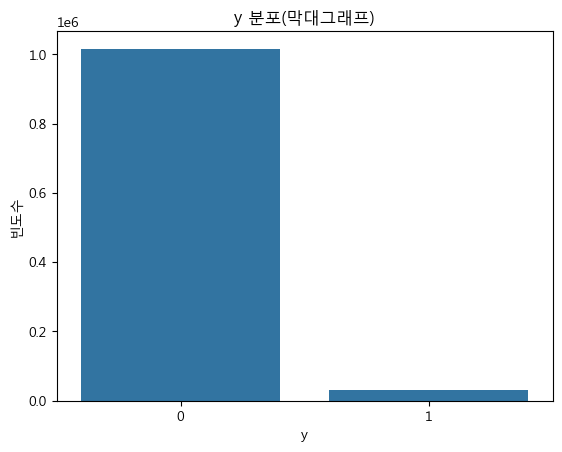

변수명: msg_length
데이터 유형: int64
기초 통계량:
count    1.048036e+06
mean     1.007307e+02
std      9.475957e+01
min      1.700000e+01
25%      3.000000e+01
50%      4.500000e+01
75%      1.770000e+02
max      3.290000e+02
Name: msg_length, dtype: float64


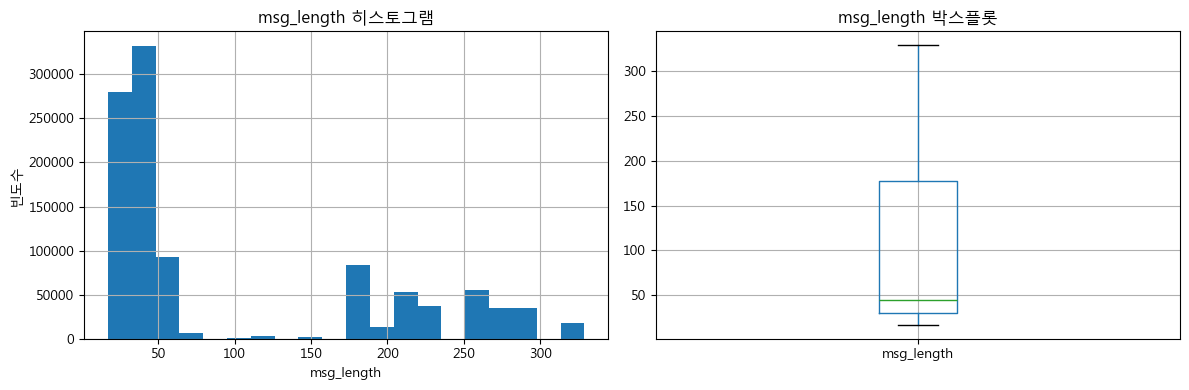

변수명: max_discount
데이터 유형: float64
기초 통계량:
count    1.048036e+06
mean     3.318570e+01
std      2.105396e+01
min      0.000000e+00
25%      2.800000e+01
50%      3.333333e+01
75%      5.000000e+01
max      1.000000e+02
Name: max_discount, dtype: float64


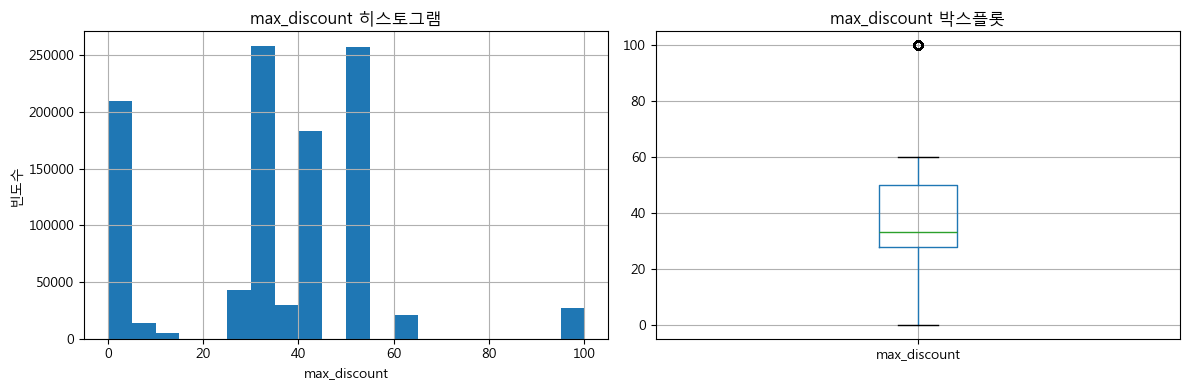

변수명: personalized
데이터 유형: int64
기초 통계량:
count    1.048036e+06
mean     1.743146e-01
std      3.793800e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: personalized, dtype: float64
빈도 분포:
personalized
0    865348
1    182688
Name: count, dtype: int64


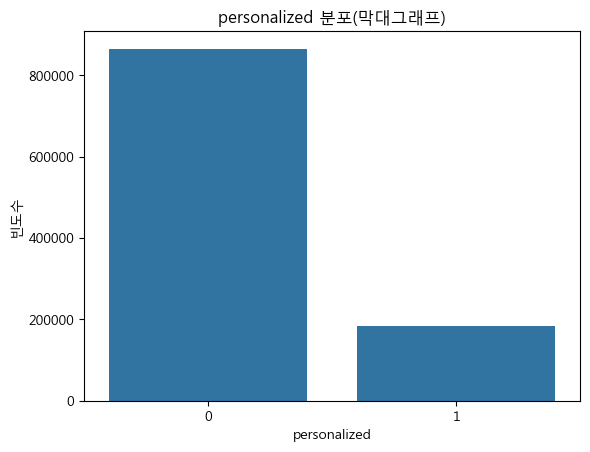

변수명: time_pressure
데이터 유형: int64
기초 통계량:
count    1.048036e+06
mean     3.266777e-02
std      1.777656e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: time_pressure, dtype: float64
빈도 분포:
time_pressure
0    1013799
1      34237
Name: count, dtype: int64


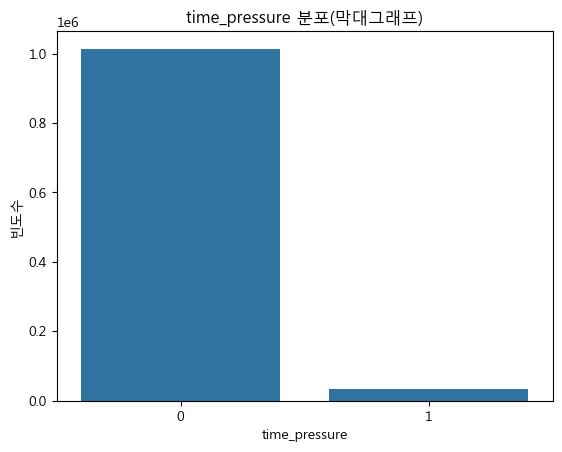

변수명: AVG_SAL_AMT
데이터 유형: float64
기초 통계량:
count    1.048036e+06
mean     1.468416e+04
std      9.174287e+03
min      0.000000e+00
25%      8.401250e+03
50%      1.421042e+04
75%      1.955167e+04
max      2.635000e+05
Name: AVG_SAL_AMT, dtype: float64


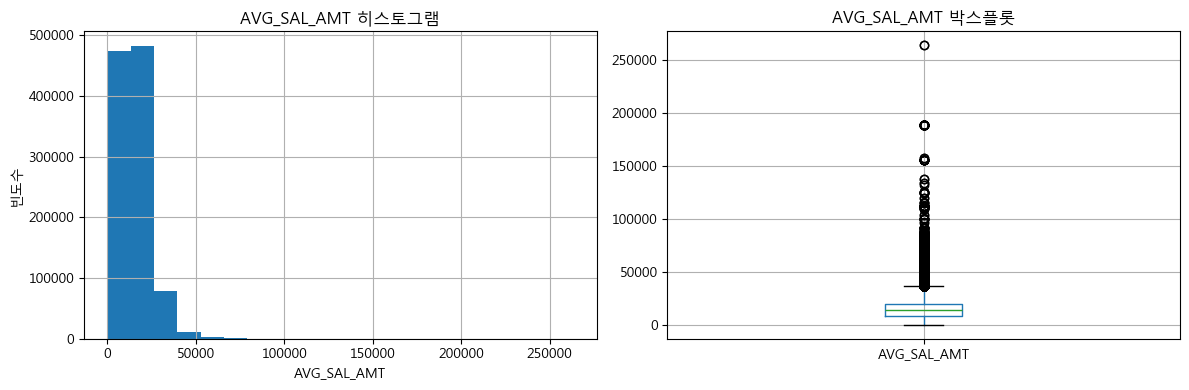

변수명: SRCH_EFRT
데이터 유형: int64
기초 통계량:
count    1.048036e+06
mean     1.654643e+01
std      2.043042e+01
min      4.000000e+00
25%      5.000000e+00
50%      9.000000e+00
75%      1.900000e+01
max      4.840000e+02
Name: SRCH_EFRT, dtype: float64


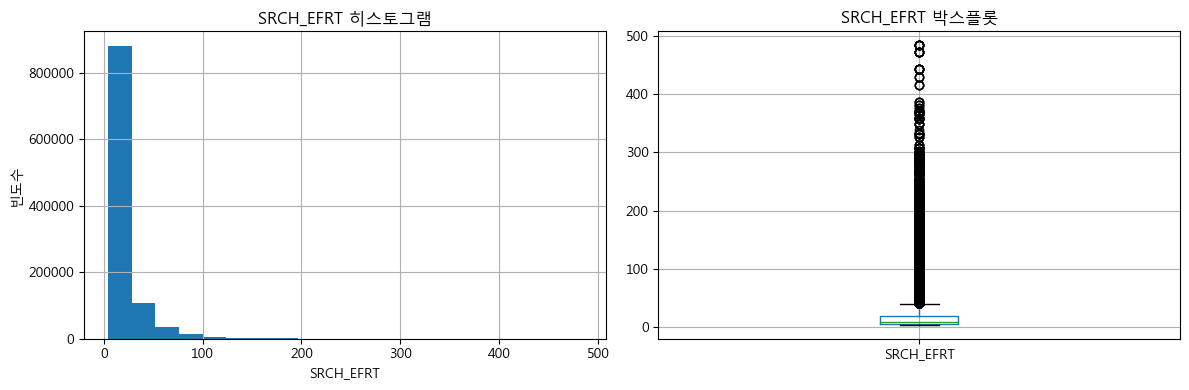

변수명: CAT_CNT
데이터 유형: int64
기초 통계량:
count    1.048036e+06
mean     5.489802e-01
std      8.325031e-01
min     -1.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      8.000000e+00
Name: CAT_CNT, dtype: float64


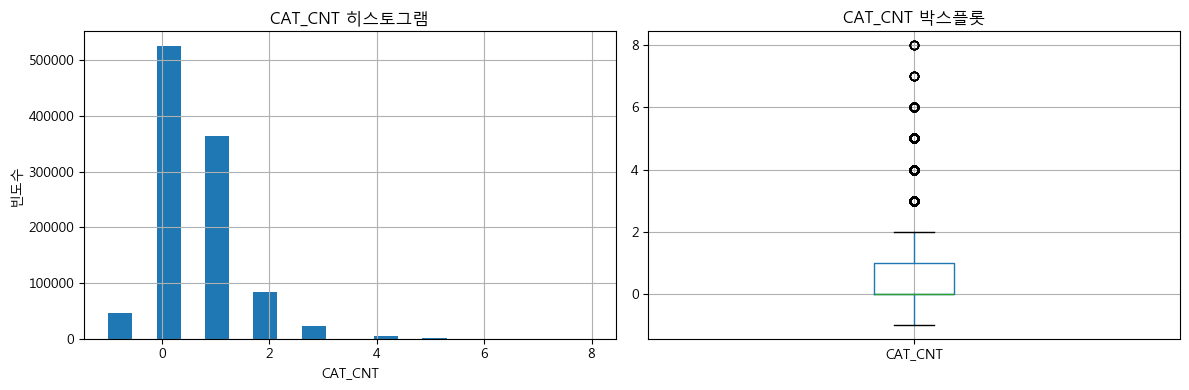

변수명: AVG_DEPTH
데이터 유형: float64
기초 통계량:
count    1.048036e+06
mean     2.615958e+01
std      1.574562e+01
min      1.000000e+01
25%      1.000000e+01
50%      2.166667e+01
75%      4.200000e+01
max      1.000000e+02
Name: AVG_DEPTH, dtype: float64


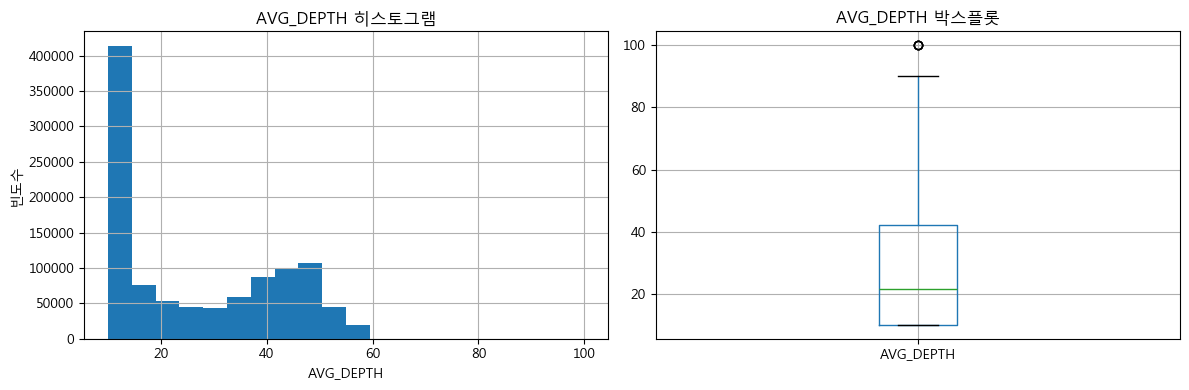

변수명: day_off
데이터 유형: int64
기초 통계량:
count    1.048036e+06
mean     5.677734e-01
std      4.953857e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: day_off, dtype: float64
빈도 분포:
day_off
1    595047
0    452989
Name: count, dtype: int64


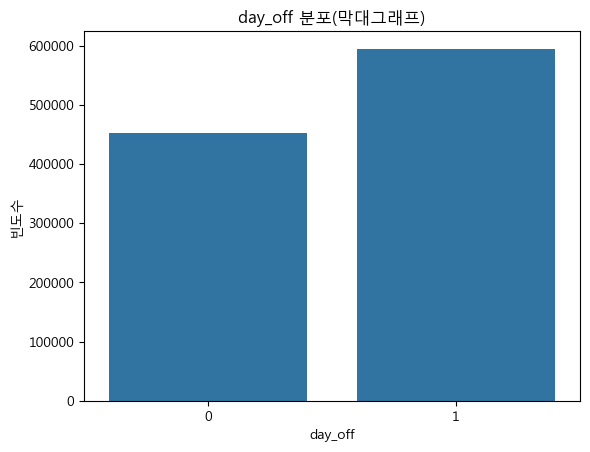

변수명: WEEKEND
데이터 유형: int64
기초 통계량:
count    1.048036e+06
mean     2.651188e-01
std      4.413966e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: WEEKEND, dtype: float64
빈도 분포:
WEEKEND
0    770182
1    277854
Name: count, dtype: int64


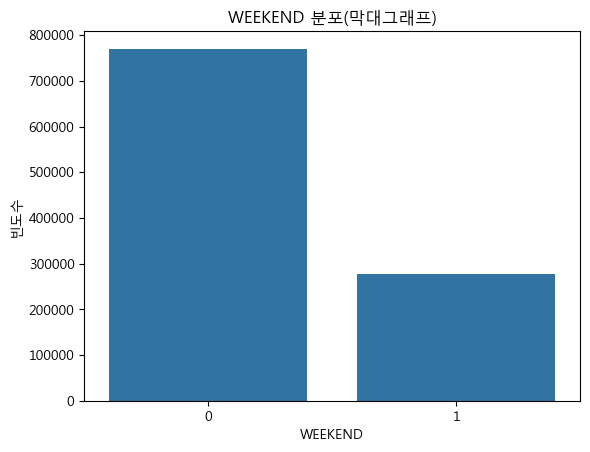

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font', family="Malgun Gothic")

import warnings 
warnings.filterwarnings("ignore")


for col in df_origin.columns:
    print('='*50)
    print(f"변수명: {col}")
    print("데이터 유형:", df_origin[col].dtype)

    # 변수에 대한 기초 통계량 출력
    print("기초 통계량:")
    print(df_origin[col].describe())

    if df_origin[col].dtype == 'object' or df_origin[col].nunique() < 10:
        temp = pd.DataFrame(df_origin[col].value_counts()).reset_index()
        print("빈도 분포:")
        print(df_origin[col].value_counts())
        # 막대그래프 그리기
        sns.barplot(x = col,
                    y = 'count',
                    data = temp)
        plt.title(f"{col} 분포(막대그래프)")
        plt.xlabel(col)
        plt.ylabel("빈도수")
        plt.show()
    else:
        # 수치형 변수의 경우 히스토그램과 박스플롯을 통해 분포 및 이상치 확인
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        df_origin[col].hist(bins=20)
        plt.title(f"{col} 히스토그램")
        plt.xlabel(col)
        plt.ylabel("빈도수")

        plt.subplot(1,2,2)
        df_origin.boxplot(column=col)
        plt.title(f"{col} 박스플롯")

        plt.tight_layout()
        plt.show()

In [70]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = 0
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

In [71]:
import statsmodels.api as sm

df_remove = df_origin[df_origin['max_discount'] < 67]
df_remove = remove_outliers(df_remove, ["AVG_SAL_AMT", "SRCH_EFRT", "CAT_CNT", "AVG_DEPTH"])

# 특징 변수와 종속 변수 분리
X = df_remove.drop(columns=['y'])  
y = df_remove['y']

# 상수항 추가
X = sm.add_constant(X)

# 로지스틱 회귀 모델 생성 및 학습
model = sm.Logit(y, X)
result = model.fit()

result.summary()

Optimization terminated successfully.
         Current function value: 0.133394
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:               855432
Model:                          Logit   Df Residuals:                   855421
Method:                           MLE   Df Model:                           10
Date:                Wed, 18 Jun 2025   Pseudo R-squ.:                 0.03651
Time:                        20:55:15   Log-Likelihood:            -1.1411e+05
converged:                       True   LL-Null:                   -1.1843e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -2.9584      0.023   -130.457      0.000      -3.003      -2.914
msg_length        0.0016      0.000     14.031      0.000       0.001       0.002
max_discount     -0.0199      0.000    -55.937      0.000      -0.021      -0.019
personalized      0.1994      0.028      7.106      0.000       0.144       0.254
time_pressure     0.9578      0.025     38.997      0.000       0.910       1.006
AVG_SAL_AMT    1.132e-06   8.31e-07      1.362      0.173   -4.97e-07    2.76e-06
SRCH_EFRT        -0.0031      0.001     -3.515      0.000      -0.005      -0.001
CAT_CNT           0.0191      0.012      1.610      0.107      -0.004       0.042
AVG_DEPTH         0.0011      0.000      2.428      0.015       0.000       0.002
day_off          -0.0112      0.013     -0.880      0.379      -0.036       0.014
WEEKEND          -0.9755      0.019    -51.838      0.000      -1.012      -0.939
=================================================================================
"""

### 교호작용항 추가

In [72]:
df_control = df[['y', 'msg_length', 'max_discount', 'personalized', 'time_pressure', 'AVG_SAL_AMT', 'SRCH_EFRT', 'CAT_CNT',
       'AVG_DEPTH', 'day_off', 'WEEKEND', 'SEX_CD', 'AGE']]

df_control = df_control[df_control['max_discount'] < 67]
df_control = remove_outliers(df_control, ["AVG_SAL_AMT", "SRCH_EFRT", "CAT_CNT", "AVG_DEPTH"])

dl = ['msg_length', 'max_discount', 'personalized', 'time_pressure']
ml = ['AVG_SAL_AMT', 'SRCH_EFRT', 'CAT_CNT', 'AVG_DEPTH', 'day_off', 'WEEKEND']

df_m = df_control.copy()

for d in dl:
    for m in ml:
       interaction_term = f"{d}_x_{m}"  # 교호작용항 이름 설정
       df_m[interaction_term] = df_m[d] * df_m[m]  # 교호작용항 계산

interaction_term = ['y', 'msg_length', 'max_discount', 'personalized', 'time_pressure', 'AVG_SAL_AMT', 'SRCH_EFRT', 'CAT_CNT',
       'AVG_DEPTH', 'day_off', 'WEEKEND',
       # 'msg_length_x_SRCH_EFRT', 
       # 'msg_length_x_CAT_CNT', 
       'msg_length_x_AVG_DEPTH', 'max_discount_x_AVG_SAL_AMT', 
       'max_discount_x_AVG_DEPTH', 
       'time_pressure_x_SRCH_EFRT', 'time_pressure_x_CAT_CNT', 'time_pressure_x_day_off', 'time_pressure_x_WEEKEND',
       'SEX_CD', 'AGE']

df_m = df_m[interaction_term]
df_m.head(2)

,y,msg_length,max_discount,personalized,time_pressure,AVG_SAL_AMT,SRCH_EFRT,CAT_CNT,AVG_DEPTH,day_off,WEEKEND,msg_length_x_AVG_DEPTH,max_discount_x_AVG_SAL_AMT,max_discount_x_AVG_DEPTH,time_pressure_x_SRCH_EFRT,time_pressure_x_CAT_CNT,time_pressure_x_day_off,time_pressure_x_WEEKEND,SEX_CD,AGE
0,0,30,32.0,0,0,21490.0,6,0,24.285714,1,0,728.571429,687680.0,777.142857,0,0,0,0,1,40
1,0,41,0.0,0,0,26085.0,15,0,16.666667,0,1,683.333333,0.0,0.000000,0,0,0,0,1,50


In [73]:
# 특징 변수와 종속 변수 분리
X = df_m.drop(columns=['y'])  
y = df_m['y']

# 상수항 추가
X = sm.add_constant(X)

# 로지스틱 회귀 모델 생성 및 학습
model = sm.Logit(y, X)
result = model.fit()

result.summary()

         Current function value: 0.132942
         Iterations: 35


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:               855432
Model:                          Logit   Df Residuals:                   855412
Method:                           MLE   Df Model:                           19
Date:                Wed, 18 Jun 2025   Pseudo R-squ.:                 0.03977
Time:                        20:55:21   Log-Likelihood:            -1.1372e+05
converged:                      False   LL-Null:                   -1.1843e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -3.0895      0.043    -71.584      0.000      -3.174      -3.005
msg_length                     0.0021      0.000     13.940      0.000       0.002       0.002
max_discount                  -0.0175      0.001    -22.285      0.000      -0.019      -0.016
personalized                   0.2233      0.028      7.912      0.000       0.168       0.279
time_pressure                  1.1307      0.052     21.855      0.000       1.029       1.232
AVG_SAL_AMT                 6.898e-06   1.29e-06      5.360      0.000    4.38e-06    9.42e-06
SRCH_EFRT                     -0.0032      0.001     -3.480      0.001      -0.005      -0.001
CAT_CNT                        0.0277      0.012      2.252      0.024       0.004       0.052
AVG_DEPTH                      0.0026      0.001      3.364      0.001       0.001       0.004
day_off                       -0.0165      0.013     -1.244      0.214      -0.042       0.009
WEEKEND                       -0.8648      0.019    -45.706      0.000      -0.902      -0.828
msg_length_x_AVG_DEPTH     -2.187e-05   4.22e-06     -5.187      0.000   -3.01e-05   -1.36e-05
max_discount_x_AVG_SAL_AMT -2.504e-07   4.15e-08     -6.033      0.000   -3.32e-07   -1.69e-07
max_discount_x_AVG_DEPTH    3.418e-05   2.12e-05      1.612      0.107   -7.37e-06    7.57e-05
time_pressure_x_SRCH_EFRT      0.0026      0.003      0.819      0.413      -0.004       0.009
time_pressure_x_CAT_CNT       -0.1362      0.046     -2.968      0.003      -0.226      -0.046
time_pressure_x_day_off        0.0908      0.049      1.842      0.065      -0.006       0.187
time_pressure_x_WEEKEND      -20.3517   1289.163     -0.016      0.987   -2547.065    2506.362
SEX_CD                        -0.0218      0.021     -1.038      0.299      -0.063       0.019
AGE                            0.0006      0.001      0.858      0.391      -0.001       0.002
==============================================================================================
"""

### 모델 평가

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

logit = LogisticRegression()
logit.fit(X,y)
X.head(2)

,const,msg_length,max_discount,personalized,time_pressure,AVG_SAL_AMT,SRCH_EFRT,CAT_CNT,AVG_DEPTH,day_off,WEEKEND,msg_length_x_AVG_DEPTH,max_discount_x_AVG_SAL_AMT,max_discount_x_AVG_DEPTH,time_pressure_x_SRCH_EFRT,time_pressure_x_CAT_CNT,time_pressure_x_day_off,time_pressure_x_WEEKEND,SEX_CD,AGE
0,1.0,30,32.0,0,0,21490.0,6,0,24.285714,1,0,728.571429,687680.0,777.142857,0,0,0,0,1,40
1,1.0,41,0.0,0,0,26085.0,15,0,16.666667,0,1,683.333333,0.0,0.000000,0,0,0,0,1,50


In [75]:
predict = logit.predict(X)

# 분류모델 평가
print('accuracy score:', accuracy_score(y, predict))
print('f1_score score:', f1_score(y, predict))
print('recall score:', recall_score(y, predict))
print('precision score', precision_score(y, predict))

accuracy score: 0.9689279802485762
f1_score score: 0.0
recall score: 0.0
precision score 0.0


### 변수 확인

In [76]:
import numpy as np

# 상관 계수 행렬 계산
corr_matrix = X.corr().abs()

# 상관 계수가 높은 변수 찾기
high_corr_var = np.where(corr_matrix > 0.7)
high_corr_var = [(corr_matrix.index[x], corr_matrix.columns[y]) for x, y in zip(*high_corr_var) if x != y and x < y]

# 높은 상관 관계를 갖는 변수 출력
print("상관 관계가 높은 변수들:", high_corr_var)

상관 관계가 높은 변수들: [('msg_length', 'personalized'), ('msg_length', 'msg_length_x_AVG_DEPTH'), ('time_pressure', 'time_pressure_x_SRCH_EFRT'), ('time_pressure', 'time_pressure_x_day_off'), ('AVG_DEPTH', 'max_discount_x_AVG_DEPTH'), ('time_pressure_x_SRCH_EFRT', 'time_pressure_x_CAT_CNT')]


In [77]:
# 다중공선성
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

df_X = df_control.drop(columns=['y'])

def calculate_vif(df):
    df_const = add_constant(df)
    vif = pd.DataFrame()
    vif["feature"] = df_const.columns
    vif["VIF"] = [variance_inflation_factor(df_const.values, i) for i in range(df_const.shape[1])]
    return vif

vif_df = calculate_vif(df_X)
print(vif_df)

          feature        VIF
0           const  38.236238
1      msg_length   2.886225
2    max_discount   1.084543
3    personalized   3.027696
4   time_pressure   1.020416
5     AVG_SAL_AMT   1.068893
6       SRCH_EFRT   1.446501
7         CAT_CNT   1.334177
8       AVG_DEPTH   1.186597
9         day_off   1.014530
10        WEEKEND   1.001423
11         SEX_CD   1.007905
12            AGE   1.017385


In [78]:
df_X.corr()

,msg_length,max_discount,personalized,time_pressure,AVG_SAL_AMT,SRCH_EFRT,CAT_CNT,AVG_DEPTH,day_off,WEEKEND,SEX_CD,AGE
msg_length,1.000000,0.067632,0.799585,-0.107322,0.078751,0.028016,0.020617,0.017916,0.000811,-0.016086,-0.018001,-0.011604
max_discount,0.067632,1.000000,0.208484,-0.078748,0.072393,0.034960,0.036567,0.037460,-0.015298,-0.008379,0.005483,0.015646
personalized,0.799585,0.208484,1.000000,-0.085474,0.138472,0.059357,0.056155,0.066552,-0.024590,-0.015387,-0.022252,-0.007036
time_pressure,-0.107322,-0.078748,-0.085474,1.000000,0.037766,0.012656,0.006699,0.019937,-0.009026,0.011866,-0.002571,0.011753
AVG_SAL_AMT,0.078751,0.072393,0.138472,0.037766,1.000000,0.107097,0.138653,0.143014,-0.077689,-0.008558,-0.028595,0.086648
SRCH_EFRT,0.028016,0.034960,0.059357,0.012656,0.107097,1.000000,0.485226,0.373692,-0.048904,-0.014509,-0.008907,-0.003396
CAT_CNT,0.020617,0.036567,0.056155,0.006699,0.138653,0.485226,1.000000,0.231883,-0.089079,0.009016,0.012037,0.037106
AVG_DEPTH,0.017916,0.037460,0.066552,0.019937,0.143014,0.373692,0.231883,1.000000,-0.050132,0.001480,0.006839,-0.024959
day_off,0.000811,-0.015298,-0.024590,-0.009026,-0.077689,-0.048904,-0.089079,-0.050132,1.000000,-0.018168,0.003370,-0.026085
WEEKEND,-0.016086,-0.008379,-0.015387,0.011866,-0.008558,-0.014509,0.009016,0.001480,-0.018168,1.000000,-0.002780,0.004210


### 독립성

In [79]:
from statsmodels.stats.stattools import durbin_watson

model2 = sm.GLM(y, X, family=sm.families.Binomial())
result2 = model2.fit()

residuals = result2.resid_deviance
dw_stat = durbin_watson(residuals)

print("Durbin-Watson 통계량:", dw_stat)

Durbin-Watson 통계량: 1.3877742701701958


## 추가분석

In [80]:
from scipy.stats import chi2

pred_prob = result.predict(X)

pred_df = pd.DataFrame({
    'y' : y,
    'pred_prob' : pred_prob
})

pred_df['decile'] = pd.qcut(pred_df['pred_prob'], 10, labels=False)

hl_data = pred_df.groupby('decile').apply(
    lambda group: pd.Series({
        'observed_positivies': group['y'].sum(),
        'observed_negatives': group['y'].count() - group['y'].sum(),
        'expected_positivies': group['pred_prob'].sum(),
        'expected_negatives': group['pred_prob'].count() - group['pred_prob'].sum()
    })
)

hl_data['chi2'] = (
    (hl_data['observed_positivies'] - hl_data['expected_positivies'])**2 / hl_data['expected_positivies'] + 
    (hl_data['observed_negatives'] - hl_data['expected_positivies'])**2 / hl_data['expected_negatives']
)

hl_stat = hl_data['chi2'].sum()
dfree = 10-2
p_value = 1 - chi2.cdf(hl_stat, dfree)

print("Hosmer-Lemeshow ch2 통계량 : ", hl_stat)
print("자유도 : ", dfree)
print("p-value : ", p_value)

Hosmer-Lemeshow ch2 통계량 :  780166.7324205898
자유도 :  8
p-value :  0.0


In [81]:
def geometric_mean(data):
    data = np.array(data)
    if np.any(data <= 0):
        raise ValueError
    return np.exp(np.mean(np.log(data)))

g_mean = geometric_mean(pred_prob)
print("예측 확률의 기하 평균:", g_mean)

예측 확률의 기하 평균: 0.02198098326439057


### ROC-AUC 

ROC-AUC: 0.6542946676004249


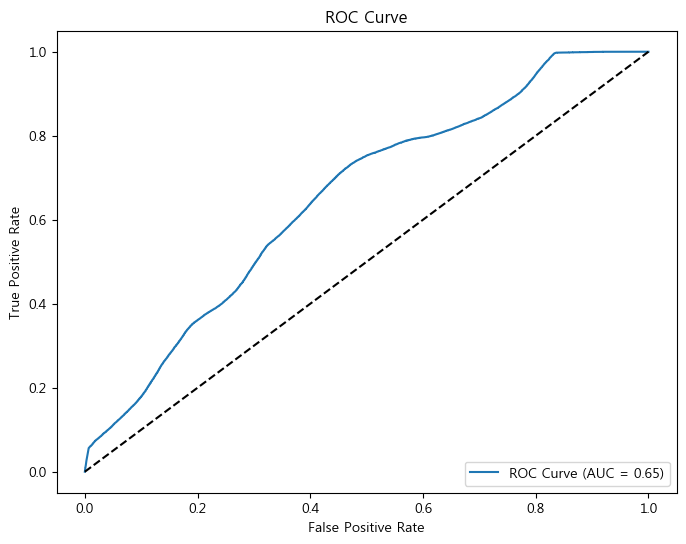

In [82]:
from sklearn.metrics import roc_auc_score, roc_curve
roc_auc = roc_auc_score(y, pred_prob)
print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y, pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()